In [8]:
!pip install -q vaderSentiment xgboost scikit-learn httpx

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import joblib

In [10]:
np.random.seed(42)
n_samples = 5000

data = {
    "youtube_growth_24h": np.random.exponential(50, n_samples),
    "youtube_growth_48h": np.random.exponential(80, n_samples),
    "youtube_growth_7d": np.random.exponential(200, n_samples),
    "reddit_mentions_24h": np.random.poisson(15, n_samples),
    "youtube_comments": np.random.exponential(10000, n_samples),
    "lastfm_playcount": np.random.exponential(500000, n_samples),
    "lastfm_listeners": np.random.exponential(50000, n_samples),
    "genre_popularity": np.random.uniform(0, 1, n_samples),
    "artist_playcount": np.random.exponential(5000000, n_samples),
    "month": np.random.randint(1, 13, n_samples),
    "is_holiday_season": np.random.choice([0, 1], n_samples, p=[0.75, 0.25]),
}
df = pd.DataFrame(data)

df["is_hit"] = (
    (df["youtube_growth_24h"] > 100) &
    (df["reddit_mentions_24h"] > 20) &
    (df["lastfm_listeners"] > 100000)
).astype(int)

print(f"Dataset: {len(df)} samples, {df['is_hit'].sum()} hits ({df['is_hit'].mean():.1%})")


Dataset: 5000 samples, 9 hits (0.2%)


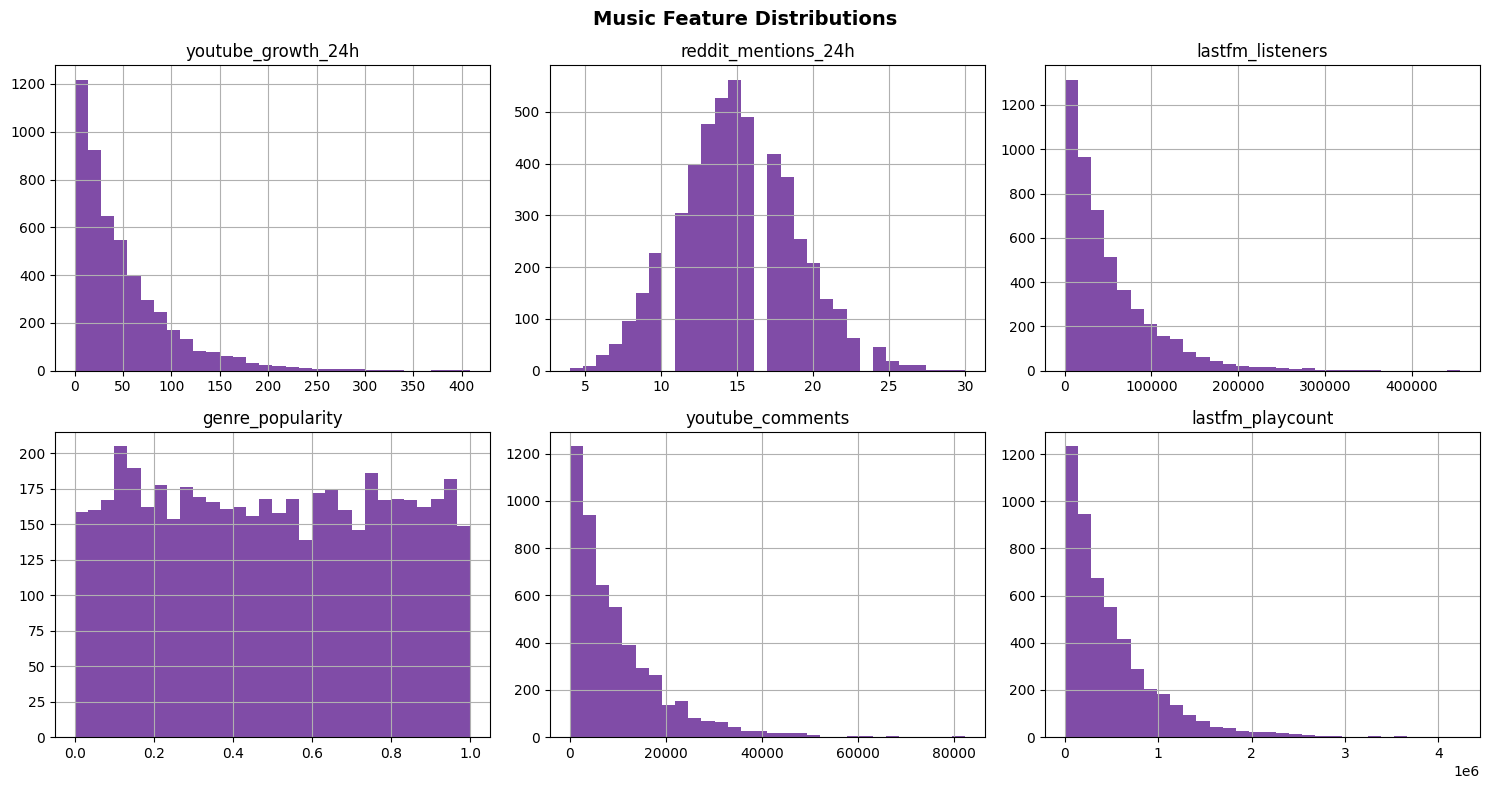

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Music Feature Distributions", fontsize=14, fontweight='bold')

features = ["youtube_growth_24h", "reddit_mentions_24h", "lastfm_listeners",
            "genre_popularity", "youtube_comments", "lastfm_playcount"]
for ax, feat in zip(axes.flatten(), features):
    df[feat].hist(bins=30, ax=ax, color='indigo', alpha=0.7)
    ax.set_title(feat)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()

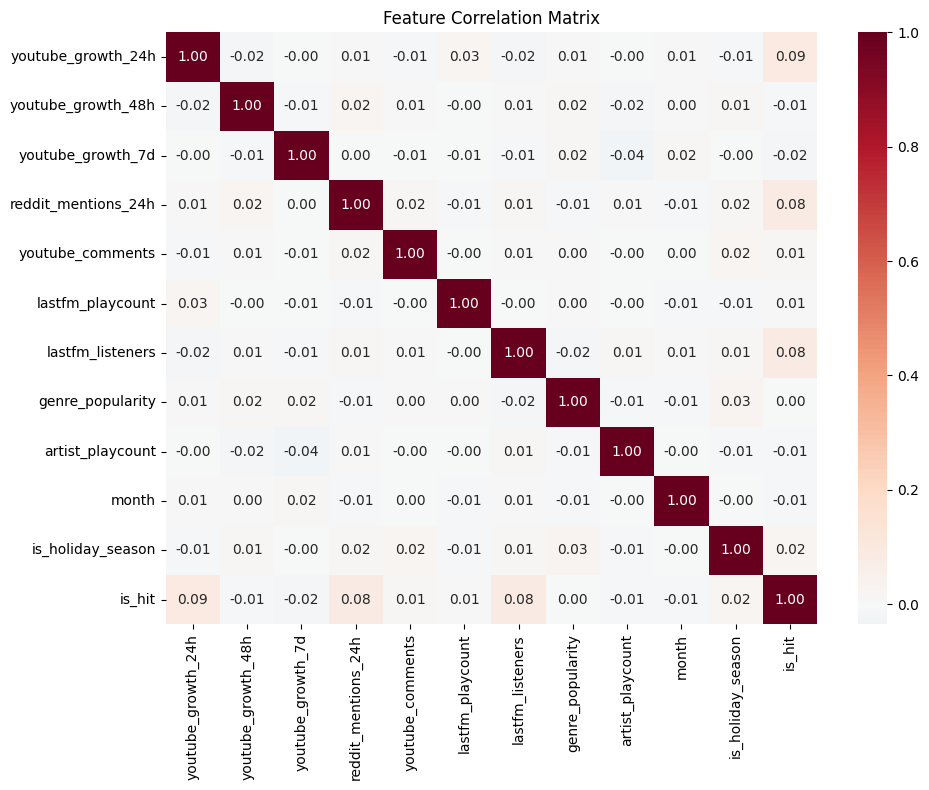

In [12]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [13]:
feature_cols = [c for c in df.columns if c != "is_hit"]
X = df[feature_cols].values
y = df["is_hit"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)],
          verbose=50)

[0]	validation_0-logloss:0.02068
[50]	validation_0-logloss:0.00934
[100]	validation_0-logloss:0.00435
[150]	validation_0-logloss:0.00348
[200]	validation_0-logloss:0.00336
[250]	validation_0-logloss:0.00355
[299]	validation_0-logloss:0.00364


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Normal", "Hit"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")



=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       997
         Hit       1.00      0.33      0.50         3

    accuracy                           1.00      1000
   macro avg       1.00      0.67      0.75      1000
weighted avg       1.00      1.00      1.00      1000

ROC AUC: 1.0000


/tmp/ipykernel_55/1950632704.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


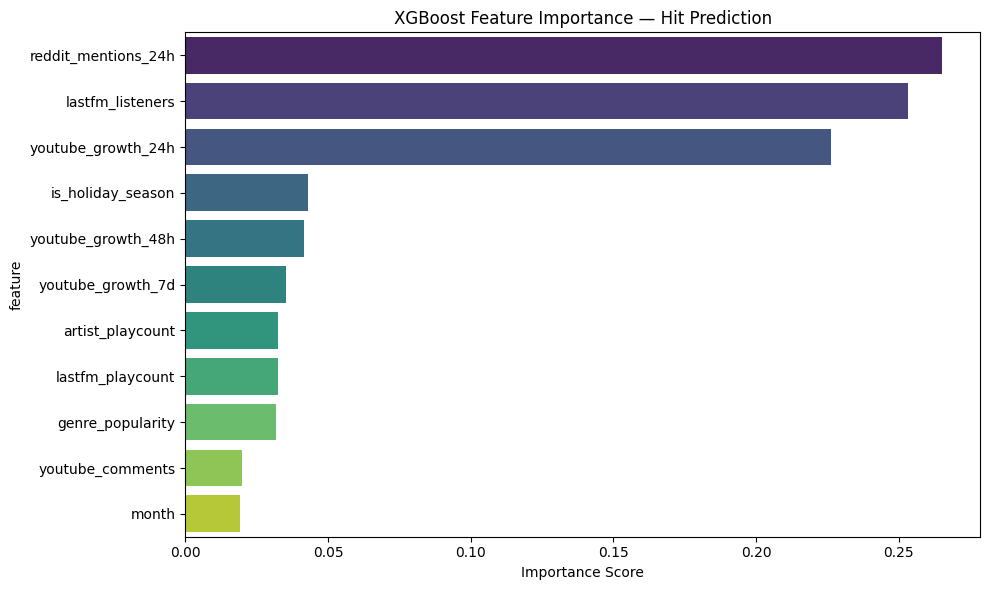

            feature  importance
reddit_mentions_24h    0.265156
   lastfm_listeners    0.253365
 youtube_growth_24h    0.226210
  is_holiday_season    0.042836
 youtube_growth_48h    0.041461
  youtube_growth_7d    0.035307
   artist_playcount    0.032627
   lastfm_playcount    0.032330
   genre_popularity    0.031820
   youtube_comments    0.019867
              month    0.019023


In [15]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("XGBoost Feature Importance — Hit Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print(importance_df.to_string(index=False))


In [16]:
joblib.dump(model, "hit_predictor.joblib")
print("\nModel saved! Download file hit_predictor.joblib")
print("Upload vào backend/models/ để sử dụng.")


Model saved! Download file hit_predictor.joblib
Upload vào backend/models/ để sử dụng.
